In [22]:
import torch
import matplotlib.pyplot as plt

In [26]:
def GramSchmidt(matrix: torch.Tensor) -> torch.Tensor:
    Q = matrix.T #.clone()

    for i in range(Q.size(0)):
        Q[i] -= Q[:i] @ Q[i] @ Q[:i]
        Q[i] /= Q[i].norm()

    return Q.T

In [27]:
def solve_utriangular(matrix: torch.Tensor, vector: torch.Tensor) -> torch.Tensor:
    x = torch.zeros_like(vector)

    for i in range(matrix.size(0)-1, -1, -1):
        x[i] = (vector[i] - matrix[i] @ x) / matrix[i, i]
    
    return x

True
False
tensor(1.4686e-06)


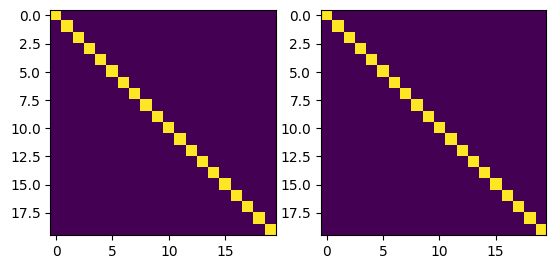

In [28]:
n = torch.tensor(20)
# A = torch.arange(1, n**2+1).reshape(n, n).float()
A = torch.randint(-100, 100, (n+10, n)).float()
Q = GramSchmidt(A)

identity = Q.T @ Q

print(torch.allclose(identity.sum(), n.float()))
print(torch.allclose(identity, torch.eye(n)))
print(torch.dist(identity, torch.eye(n)))

plt.subplot(1, 2, 1)
plt.imshow(identity)

plt.subplot(1, 2, 2)
Q, R = torch.linalg.qr(A)

plt.imshow(Q.T @ Q);

In [21]:
n = torch.tensor(5)
# A = torch.arange(1, n**2+1).reshape(n, n).float()
A = torch.randint(-100, 100, (n+10, n)).float()

Q = GramSchmidt(A)

Q.T @ Q

tensor([[ 1.0000e+00, -1.7132e-08, -3.9133e-08,  1.4910e-08, -8.9789e-10],
        [-1.7132e-08,  1.0000e+00,  2.4849e-08,  3.5542e-08,  5.6453e-10],
        [-3.9133e-08,  2.4849e-08,  1.0000e+00, -1.2454e-08, -1.5043e-09],
        [ 1.4910e-08,  3.5542e-08, -1.2454e-08,  1.0000e+00, -1.9472e-09],
        [-8.9789e-10,  5.6453e-10, -1.5043e-09, -1.9472e-09,  1.0000e+00]])